In [3]:
# Neural Network Training for Flight Delay Prediction
# This notebook trains a PyTorch model on GPU and exports to ONNX

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.onnx
import onnx
import onnxruntime as ort
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import pickle
import time
from datetime import datetime
from pathlib import Path
import json

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("="*60)
print("TRAINING ENVIRONMENT")
print("="*60)
print(f"Device: {device}")

if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    print(f"CUDA Version: {torch.version.cuda}")
    print("⚡ GPU acceleration enabled!")
else:
    print("📊 Running on CPU (training will be slower)")

print(f"PyTorch Version: {torch.__version__}")
print("="*60)

TRAINING ENVIRONMENT
Device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Memory: 8.0 GB
CUDA Version: 12.9
⚡ GPU acceleration enabled!
PyTorch Version: 2.8.0+cu129


In [4]:
# Load the processed datasets from notebook 02

print("Loading processed datasets...")

X_train = pd.read_csv('../data/processed/X_train.csv')
X_val = pd.read_csv('../data/processed/X_val.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')

y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_val = pd.read_csv('../data/processed/y_val.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

print("✓ Data loaded!")
print(f"\nDataset sizes:")
print(f"  Training:   {X_train.shape[0]:,} samples × {X_train.shape[1]} features")
print(f"  Validation: {X_val.shape[0]:,} samples × {X_val.shape[1]} features")
print(f"  Test:       {X_test.shape[0]:,} samples × {X_test.shape[1]} features")

print(f"\nClass distribution:")
print(f"  Train - Delayed: {y_train.mean()*100:.1f}%")
print(f"  Val   - Delayed: {y_val.mean()*100:.1f}%")
print(f"  Test  - Delayed: {y_test.mean()*100:.1f}%")

print(f"\nFeature names:")
print(X_train.columns.tolist())

Loading processed datasets...
✓ Data loaded!

Dataset sizes:
  Training:   3,623,648 samples × 45 features
  Validation: 1,207,883 samples × 45 features
  Test:       1,207,883 samples × 45 features

Class distribution:
  Train - Delayed: 20.0%
  Val   - Delayed: 20.0%
  Test  - Delayed: 20.0%

Feature names:
['month', 'day_of_month', 'day_of_week', 'dep_hour', 'dep_minute', 'arr_hour', 'is_morning', 'is_afternoon', 'is_evening', 'is_night', 'is_morning_rush', 'is_evening_rush', 'is_weekend', 'is_holiday_season', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'origin_encoded', 'dest_encoded', 'distance', 'carrier_encoded', 'origin_delay_rate', 'dest_delay_rate', 'carrier_delay_rate', 'route_delay_rate', 'origin_daily_flights', 'dest_daily_flights', 'crs_elapsed_time', 'dep_temp', 'dep_dewpoint', 'dep_pressure', 'dep_wind_dir', 'dep_wind_speed', 'dep_sky_coverage', 'dep_precip', 'arr_temp', 'arr_dewpoint', 'arr_pressure', 'arr_wind_dir', 'arr_wind_speed', 'arr_s

In [5]:
# Convert pandas DataFrames to PyTorch tensors

print("Converting to PyTorch tensors...")

# Convert to numpy arrays first
X_train_np = X_train.values.astype(np.float32)
X_val_np = X_val.values.astype(np.float32)
X_test_np = X_test.values.astype(np.float32)

y_train_np = y_train.astype(np.float32)
y_val_np = y_val.astype(np.float32)
y_test_np = y_test.astype(np.float32)

# Create PyTorch tensors and move to device
X_train_tensor = torch.FloatTensor(X_train_np).to(device)
y_train_tensor = torch.FloatTensor(y_train_np).to(device)

X_val_tensor = torch.FloatTensor(X_val_np).to(device)
y_val_tensor = torch.FloatTensor(y_val_np).to(device)

X_test_tensor = torch.FloatTensor(X_test_np).to(device)
y_test_tensor = torch.FloatTensor(y_test_np).to(device)

print("✓ Tensors created and moved to device!")
print(f"\nTensor shapes:")
print(f"  X_train: {X_train_tensor.shape}")
print(f"  y_train: {y_train_tensor.shape}")

# Create DataLoaders for batch processing
batch_size = 1024  # Large batch size for GPU efficiency

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"\nDataLoaders created with batch size: {batch_size}")
print(f"  Training batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")

Converting to PyTorch tensors...
✓ Tensors created and moved to device!

Tensor shapes:
  X_train: torch.Size([3623648, 45])
  y_train: torch.Size([3623648])

DataLoaders created with batch size: 1024
  Training batches: 3539
  Validation batches: 1180


In [6]:
class FlightDelayPredictor(nn.Module):
    """
    Enhanced Neural Network for Flight Delay Prediction
    
    Architecture optimized for:
    - 45 input features (including weather)
    - 6M training samples
    - Imbalanced binary classification
    """
    
    def __init__(self, input_size=45):
        super(FlightDelayPredictor, self).__init__()
        
        # Layer 1: Expand to capture feature interactions
        self.fc1 = nn.Linear(input_size, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.dropout1 = nn.Dropout(0.3)
        
        # Layer 2: Maintain capacity
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(0.3)
        
        # Layer 3: Progressive compression
        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.dropout3 = nn.Dropout(0.2)
        
        # Layer 4: Final compression
        self.fc4 = nn.Linear(64, 32)
        self.bn4 = nn.BatchNorm1d(32)
        self.dropout4 = nn.Dropout(0.2)
        
        # Output layer
        self.fc5 = nn.Linear(32, 1)
        
        # Activation
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # Layer 1
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout1(x)
        
        # Layer 2
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout2(x)
        
        # Layer 3
        x = self.fc3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.dropout3(x)
        
        # Layer 4
        x = self.fc4(x)
        x = self.bn4(x)
        x = self.relu(x)
        x = self.dropout4(x)
        
        # Output (raw logits, NO sigmoid)
        x = self.fc5(x)
        
        return x

# Create model instance
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_size = 45  # Your feature count
model = FlightDelayPredictor(input_size=input_size)
model = model.to(device)

print("="*60)
print("MODEL ARCHITECTURE")
print("="*60)
print(model)
print("="*60)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Device: {device}")

MODEL ARCHITECTURE
FlightDelayPredictor(
  (fc1): Linear(in_features=45, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout3): Dropout(p=0.2, inplace=False)
  (fc4): Linear(in_features=64, out_features=32, bias=True)
  (bn4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout4): Dropout(p=0.2, inplace=False)
  (fc5): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)

Total parameters: 56,001
Trainable parameters: 56,001
Device: cuda


In [7]:
# Loss function with class weighting to handle imbalance

# Calculate class weights (inverse of class frequency)
class_counts = np.bincount(y_train.astype(int))
total_samples = len(y_train)

weight_for_0 = total_samples / (2 * class_counts[0])  # On-time
weight_for_1 = total_samples / (2 * class_counts[1])  # Delayed

print("="*60)
print("⚖️  CLASS WEIGHTING")
print("="*60)
print(f"Class 0 (On-time): {class_counts[0]:,} samples")
print(f"Class 1 (Delayed): {class_counts[1]:,} samples")
print(f"\nClass weights:")
print(f"  Weight for class 0: {weight_for_0:.3f}")
print(f"  Weight for class 1: {weight_for_1:.3f}")
print(f"  Ratio: Delayed class is {weight_for_1/weight_for_0:.2f}x more important")
print("="*60)

# Create pos_weight for BCEWithLogitsLoss
# pos_weight tells the loss how much more important the positive class (delayed) is
pos_weight = torch.tensor([weight_for_1 / weight_for_0]).to(device)

# Use BCEWithLogitsLoss (NOT BCELoss!) with pos_weight
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f"\n✓ Using BCEWithLogitsLoss with pos_weight={pos_weight.item():.3f}")
print(f"  This makes delayed flights {pos_weight.item():.2f}x more important")

# Optimizer: Adam (adaptive learning rate)
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)  # Added L2 regularization

# Learning rate scheduler (reduce LR when validation loss plateaus)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5,      # Reduce LR by half
    patience=3,      # After 3 epochs with no improvement
)

print(f"\n🎯 Optimizer: Adam (with L2 regularization λ=1e-5)")
print(f"📊 Initial Learning Rate: {learning_rate}")
print(f"📉 LR Scheduler: ReduceLROnPlateau (patience=3, factor=0.5)")

⚖️  CLASS WEIGHTING
Class 0 (On-time): 2,900,659 samples
Class 1 (Delayed): 722,989 samples

Class weights:
  Weight for class 0: 0.625
  Weight for class 1: 2.506
  Ratio: Delayed class is 4.01x more important

✓ Using BCEWithLogitsLoss with pos_weight=4.012
  This makes delayed flights 4.01x more important

🎯 Optimizer: Adam (with L2 regularization λ=1e-5)
📊 Initial Learning Rate: 0.001
📉 LR Scheduler: ReduceLROnPlateau (patience=3, factor=0.5)


In [8]:
# Training loop with validation and early stopping
from sklearn.metrics import f1_score, roc_auc_score
import time

def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs).squeeze()
        loss = criterion(outputs, targets)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        # Statistics (apply sigmoid for predictions)
        running_loss += loss.item()
        predicted = (torch.sigmoid(outputs) > 0.5).float()  # FIX: Added sigmoid
        total += targets.size(0)
        correct += (predicted == targets).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100.0 * correct / total
    
    return epoch_loss, epoch_acc

def validate(model, val_loader, criterion, device):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, targets in val_loader:
            # Forward pass
            outputs = model(inputs).squeeze()
            
            # Use the SAME criterion as training (already has pos_weight)
            loss = criterion(outputs, targets)
            
            running_loss += loss.item()
            
            # Apply sigmoid for predictions
            predictions_prob = torch.sigmoid(outputs)
            predicted = (predictions_prob > 0.5).float()
            
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
            
            # Store for metrics (use probabilities for ROC-AUC)
            all_predictions.extend(predictions_prob.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100.0 * correct / total
    
    # Calculate additional metrics
    predictions_binary = (np.array(all_predictions) > 0.5).astype(int)
    f1 = f1_score(all_targets, predictions_binary)
    roc_auc = roc_auc_score(all_targets, all_predictions)
    
    return epoch_loss, epoch_acc, f1, roc_auc

# Training configuration
num_epochs = 20
best_val_loss = float('inf')
best_model_state = None
patience = 5
patience_counter = 0

# Storage for metrics
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': [],
    'val_roc_auc': []
}

print("="*60)
print("TRAINING START")
print("="*60)
print(f"Epochs: {num_epochs}")
print(f"Batch size: 1024")
print(f"Early stopping patience: {patience}")
print(f"Class weighting: 4.01x on delayed flights")
print("="*60)

start_time = time.time()

# Training loop
for epoch in range(num_epochs):
    epoch_start = time.time()
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc, val_f1, val_roc_auc = validate(model, val_loader, criterion, device)
    
    # Store metrics
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['val_roc_auc'].append(val_roc_auc)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        best_epoch = epoch + 1
        improved = True
    else:
        patience_counter += 1
        improved = False
    
    epoch_time = time.time() - epoch_start
    
    # Print progress
    print(f"Epoch [{epoch+1}/{num_epochs}] ({epoch_time:.1f}s)")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"  Val F1:     {val_f1:.4f} | Val ROC-AUC: {val_roc_auc:.4f}")
    
    if improved:
        print(f"++ BEST MODEL SO FAR ++")
    
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        print(f"  Best epoch was {best_epoch} with val_loss={best_val_loss:.4f}")
        break
    
    print("-" * 60)

total_time = time.time() - start_time

print("="*60)
print("TRAINING COMPLETE")
print("="*60)
print(f"Total training time: {total_time/60:.1f} minutes")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Best epoch: {best_epoch}")
print("="*60)

# Load best model
model.load_state_dict(best_model_state)
print("✓ Best model weights loaded")

TRAINING START
Epochs: 20
Batch size: 1024
Early stopping patience: 5
Class weighting: 4.01x on delayed flights
Epoch [1/20] (29.6s)
  Train Loss: 1.0040 | Train Acc: 65.09%
  Val Loss:   0.9889 | Val Acc:   65.38%
  Val F1:     0.4354 | Val ROC-AUC: 0.7176
++ BEST MODEL SO FAR ++
------------------------------------------------------------
Epoch [2/20] (30.5s)
  Train Loss: 0.9912 | Train Acc: 66.22%
  Val Loss:   0.9814 | Val Acc:   66.58%
  Val F1:     0.4419 | Val ROC-AUC: 0.7245
++ BEST MODEL SO FAR ++
------------------------------------------------------------
Epoch [3/20] (33.2s)
  Train Loss: 0.9858 | Train Acc: 66.94%
  Val Loss:   0.9763 | Val Acc:   66.48%
  Val F1:     0.4446 | Val ROC-AUC: 0.7283
++ BEST MODEL SO FAR ++
------------------------------------------------------------
Epoch [4/20] (32.5s)
  Train Loss: 0.9826 | Train Acc: 67.06%
  Val Loss:   0.9737 | Val Acc:   67.28%
  Val F1:     0.4471 | Val ROC-AUC: 0.7303
++ BEST MODEL SO FAR ++
-------------------------

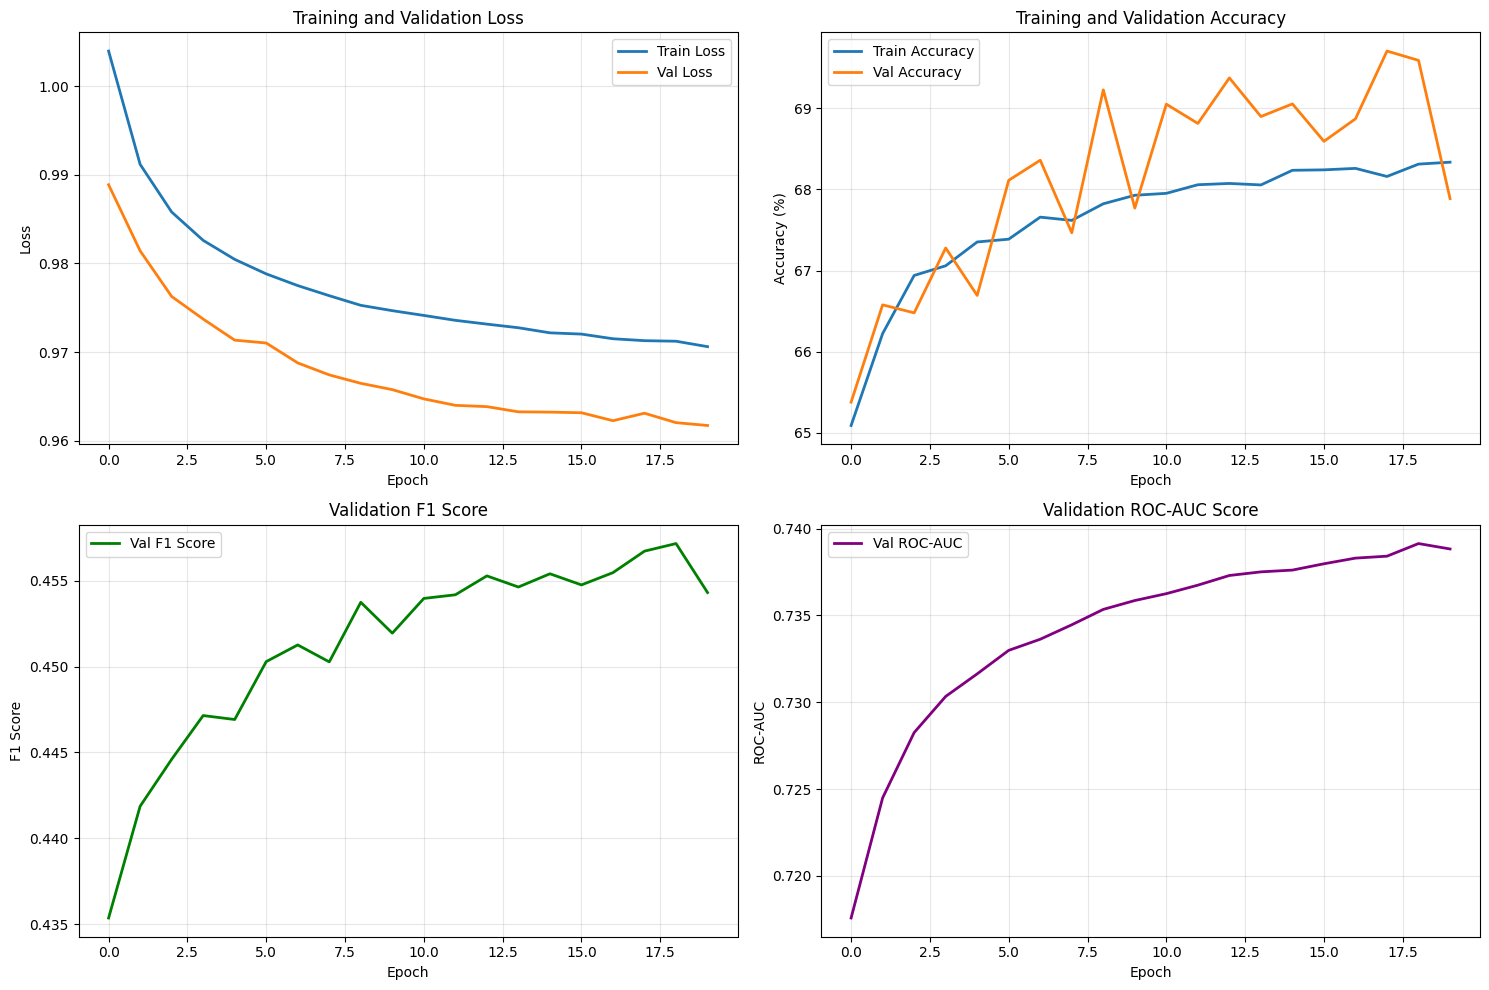

✓ Training history plot saved to ../data/models/training_history.png


In [9]:
# Plot training and validation metrics

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Accuracy
axes[0, 1].plot(history['train_acc'], label='Train Accuracy', linewidth=2)
axes[0, 1].plot(history['val_acc'], label='Val Accuracy', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: F1 Score
axes[1, 0].plot(history['val_f1'], label='Val F1 Score', color='green', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('Validation F1 Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: ROC-AUC
axes[1, 1].plot(history['val_roc_auc'], label='Val ROC-AUC', color='purple', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('ROC-AUC')
axes[1, 1].set_title('Validation ROC-AUC Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/models/training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training history plot saved to ../data/models/training_history.png")

# Hyperparameter Tuning with Optuna

In [10]:
import optuna
from optuna.trial import TrialState

# Define flexible model architecture for Optuna

class FlexibleFlightDelayPredictor(nn.Module):
    """
    Flexible architecture that Optuna can tune
    """
    def __init__(self, input_size, hidden_sizes, dropout_rates):
        super(FlexibleFlightDelayPredictor, self).__init__()
        
        layers = []
        prev_size = input_size
        
        for i, (hidden_size, dropout) in enumerate(zip(hidden_sizes, dropout_rates)):
            # Linear layer
            layers.append(nn.Linear(prev_size, hidden_size))
            # Batch norm
            layers.append(nn.BatchNorm1d(hidden_size))
            # Activation
            layers.append(nn.ReLU())
            # Dropout
            layers.append(nn.Dropout(dropout))
            
            prev_size = hidden_size
        
        # Output layer
        layers.append(nn.Linear(prev_size, 1))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x).squeeze()

print("✓ Flexible model architecture defined")

✓ Flexible model architecture defined


In [11]:
# Optuna objective function

def objective(trial):
    """
    Optuna will call this function with different hyperparameters
    """
    
    # 1. Suggest hyperparameters
    n_layers = trial.suggest_int('n_layers', 3, 5)
    
    hidden_sizes = []
    dropout_rates = []
    
    for i in range(n_layers):
        # Each layer can have different size
        hidden_size = trial.suggest_int(f'hidden_size_L{i}', 64, 512, step=64)
        dropout = trial.suggest_float(f'dropout_L{i}', 0.1, 0.5)
        
        hidden_sizes.append(hidden_size)
        dropout_rates.append(dropout)
    
    # Learning rate
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    
    # Weight decay (L2 regularization)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    
    # Class weight
    pos_weight_value = trial.suggest_float('pos_weight', 2.5, 7.0)
    
    # Batch size
    batch_size = trial.suggest_categorical('batch_size', [512, 1024, 2048])
    
    print(f"\nTrial {trial.number}: Testing configuration...")
    print(f"  Layers: {n_layers}")
    print(f"  Hidden sizes: {hidden_sizes}")
    print(f"  Dropout rates: {dropout_rates}")
    print(f"  Learning rate: {lr:.6f}")
    print(f"  pos_weight: {pos_weight_value:.3f}")
    print(f"  Batch size: {batch_size}")
    
    # 2. Create model with these hyperparameters
    model = FlexibleFlightDelayPredictor(
        input_size=45,
        hidden_sizes=hidden_sizes,
        dropout_rates=dropout_rates
    ).to(device)
    
    # 3. Create DataLoaders with suggested batch size
    train_loader_trial = torch.utils.data.DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True
    )
    val_loader_trial = torch.utils.data.DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False
    )
    
    # 4. Create loss and optimizer
    pos_weight = torch.tensor([pos_weight_value]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(
        model.parameters(), 
        lr=lr, 
        weight_decay=weight_decay
    )
    
    # 5. Train for limited epochs (quick evaluation)
    n_epochs = 10  # Quick training for each trial
    best_f1 = 0
    
    for epoch in range(n_epochs):
        # Train
        model.train()
        for inputs, targets in train_loader_trial:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
        
        # Validate
        model.eval()
        all_predictions = []
        all_targets = []
        
        with torch.no_grad():
            for inputs, targets in val_loader_trial:
                outputs = model(inputs)
                predictions_prob = torch.sigmoid(outputs)
                
                all_predictions.extend(predictions_prob.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())
        
        # Calculate F1
        predictions_binary = (np.array(all_predictions) > 0.5).astype(int)
        f1 = f1_score(all_targets, predictions_binary)
        
        if f1 > best_f1:
            best_f1 = f1
        
        # Report intermediate value for pruning
        trial.report(f1, epoch)
        
        # Prune unpromising trials
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    print(f"  → Best F1: {best_f1:.4f}")
    
    return best_f1

print("✓ Objective function defined")

✓ Objective function defined


In [13]:
# Cell 11B: Quick Model Reconstruction (skip Optuna training)
# Use this cell when you already have trained weights and just need the model object

import torch
import torch.nn as nn
import joblib

print("="*60)
print("RECONSTRUCTING TRAINED MODEL FROM SAVED FILES")
print("="*60)

# 1. Load Optuna study to get architecture
study = joblib.load('../data/models/optuna_study.pkl')
best_params = study.best_params

print(f"\nBest F1-Score from Optuna: {study.best_value:.4f}")
print(f"\nBest Hyperparameters:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

# 2. Extract architecture parameters
n_layers = best_params['n_layers']
hidden_sizes = []
dropout_rates = []

for i in range(n_layers):
    hidden_sizes.append(best_params[f'hidden_size_L{i}'])
    dropout_rates.append(best_params[f'dropout_L{i}'])

print(f"\nArchitecture:")
print(f"  Number of layers: {n_layers}")
print(f"  Hidden sizes: {hidden_sizes}")
print(f"  Dropout rates: {dropout_rates}")

# 3. Recreate the model with the same architecture
input_size = 45  # Your model has 45 features
model = FlexibleFlightDelayPredictor(
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    dropout_rates=dropout_rates
).to(device)

# 4. Load the trained weights
model_path = 'data/models/flight_delay_model.pth'
model.load_state_dict(torch.load(model_path))
model.eval()  # Set to evaluation mode

print(f"\n✓ Model reconstructed and weights loaded from: {model_path}")
print(f"✓ Model has {sum(p.numel() for p in model.parameters()):,} parameters")

# 5. Load training data dimensions (needed for metadata)
import pandas as pd

X_train = pd.read_csv('../data/processed/X_train.csv')
X_val = pd.read_csv('../data/processed/X_val.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')

print(f"\n✓ Data loaded:")
print(f"  Training samples: {len(X_train):,}")
print(f"  Validation samples: {len(X_val):,}")
print(f"  Test samples: {len(X_test):,}")

# 6. Create a dummy history object (since we're not re-training)
# You can populate this with actual values from your training run if you saved them
history = {
    'note': 'Model was previously trained. Load actual training_history.json if available.',
    'architecture': hidden_sizes,
    'best_params': best_params
}

RECONSTRUCTING TRAINED MODEL FROM SAVED FILES

Best F1-Score from Optuna: 0.4636

Best Hyperparameters:
  n_layers: 5
  hidden_size_L0: 512
  dropout_L0: 0.14350756126780426
  hidden_size_L1: 320
  dropout_L1: 0.1987285920402758
  hidden_size_L2: 320
  dropout_L2: 0.44994845799161665
  hidden_size_L3: 128
  dropout_L3: 0.31169496224112386
  hidden_size_L4: 320
  dropout_L4: 0.30003134854963215
  lr: 0.0016643021457775557
  weight_decay: 1.7855630333727982e-06
  pos_weight: 3.5201653792499474
  batch_size: 512

Architecture:
  Number of layers: 5
  Hidden sizes: [512, 320, 320, 128, 320]
  Dropout rates: [0.14350756126780426, 0.1987285920402758, 0.44994845799161665, 0.31169496224112386, 0.30003134854963215]

✓ Model reconstructed and weights loaded from: data/models/flight_delay_model.pth
✓ Model has 376,321 parameters

✓ Data loaded:
  Training samples: 3,623,648
  Validation samples: 1,207,883
  Test samples: 1,207,883


In [14]:
# Run Optuna optimization

print("="*60)
print("🔍 OPTUNA HYPERPARAMETER OPTIMIZATION")
print("="*60)
print("Starting hyperparameter search...")
print("This will take 2-4 hours for 50 trials\n")

# Create study
study = optuna.create_study(
    direction='maximize',  # Maximize F1-score
    pruner=optuna.pruners.MedianPruner(  # Stop bad trials early
        n_startup_trials=5,
        n_warmup_steps=3
    )
)

# Run optimization
study.optimize(
    objective, 
    n_trials=50,  # Try 50 different configurations
    timeout=None,  # No time limit (use n_trials instead)
    show_progress_bar=True
)

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE")
print("="*60)

# Best trial
print(f"\n🏆 Best Trial:")
print(f"  F1-Score: {study.best_value:.4f}")
print(f"\n📊 Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Save study
import joblib
joblib.dump(study, '../data/models/optuna_study.pkl')
print(f"\n✓ Study saved to ../data/models/optuna_study.pkl")

[I 2025-12-13 15:36:14,395] A new study created in memory with name: no-name-922c4a39-4afa-4c6b-b98c-2f4183b89a73


🔍 OPTUNA HYPERPARAMETER OPTIMIZATION
Starting hyperparameter search...
This will take 2-4 hours for 50 trials



  0%|          | 0/50 [00:00<?, ?it/s]


Trial 0: Testing configuration...
  Layers: 5
  Hidden sizes: [128, 320, 384, 256, 192]
  Dropout rates: [0.14403350454310782, 0.11948826528923005, 0.21848418469312603, 0.35067962287240617, 0.15123553389843425]
  Learning rate: 0.004136
  pos_weight: 3.856
  Batch size: 1024
  → Best F1: 0.4463
[I 2025-12-13 15:41:21,625] Trial 0 finished with value: 0.4463242240267833 and parameters: {'n_layers': 5, 'hidden_size_L0': 128, 'dropout_L0': 0.14403350454310782, 'hidden_size_L1': 320, 'dropout_L1': 0.11948826528923005, 'hidden_size_L2': 384, 'dropout_L2': 0.21848418469312603, 'hidden_size_L3': 256, 'dropout_L3': 0.35067962287240617, 'hidden_size_L4': 192, 'dropout_L4': 0.15123553389843425, 'lr': 0.0041362682728484585, 'weight_decay': 4.3298742527693396e-05, 'pos_weight': 3.8556396271134643, 'batch_size': 1024}. Best is trial 0 with value: 0.4463242240267833.

Trial 1: Testing configuration...
  Layers: 3
  Hidden sizes: [320, 256, 192]
  Dropout rates: [0.45529974941013895, 0.2543052394184

In [15]:
# Load Optuna study and rebuild model with best params

import joblib
import torch.nn as nn


# Load the Optuna study
study = joblib.load('../data/models/optuna_study.pkl')

print("="*60)
print("LOADING BEST HYPERPARAMETERS FROM OPTUNA")
print("="*60)

# Get best parameters
best_params = study.best_params
print(f"\nBest F1-Score from Optuna: {study.best_value:.4f}")
print(f"\nBest Hyperparameters:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

# Extract architecture parameters
n_layers = best_params['n_layers']
hidden_sizes = []
dropout_rates = []

for i in range(n_layers):
    hidden_sizes.append(best_params[f'hidden_size_L{i}'])
    dropout_rates.append(best_params[f'dropout_L{i}'])

print(f"\nArchitecture:")
print(f"  Number of layers: {n_layers}")
print(f"  Hidden sizes: {hidden_sizes}")
print(f"  Dropout rates: {dropout_rates}")

# Rebuild the FlexibleFlightDelayPredictor class
class FlexibleFlightDelayPredictor(nn.Module):
    """
    Flexible architecture that matches Optuna's best configuration
    """
    def __init__(self, input_size, hidden_sizes, dropout_rates):
        super(FlexibleFlightDelayPredictor, self).__init__()
        
        layers = []
        prev_size = input_size
        
        for i, (hidden_size, dropout) in enumerate(zip(hidden_sizes, dropout_rates)):
            # Linear layer
            layers.append(nn.Linear(prev_size, hidden_size))
            # Batch norm
            layers.append(nn.BatchNorm1d(hidden_size))
            # Activation
            layers.append(nn.ReLU())
            # Dropout
            layers.append(nn.Dropout(dropout))
            
            prev_size = hidden_size
        
        # Output layer (raw logits)
        layers.append(nn.Linear(prev_size, 1))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x).squeeze()

# Create model with best architecture
model = FlexibleFlightDelayPredictor(
    input_size=45,  # Your feature count
    hidden_sizes=hidden_sizes,
    dropout_rates=dropout_rates
).to(device)

print(f"\n{'='*60}")
print("MODEL CREATED WITH BEST HYPERPARAMETERS")
print(f"{'='*60}")
print(model)

# Calculate number of parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Setup optimizer and criterion with best hyperparameters
pos_weight = torch.tensor([best_params['pos_weight']]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(
    model.parameters(),
    lr=best_params['lr'],
    weight_decay=best_params['weight_decay']
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

# Create DataLoaders with best batch size
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=best_params['batch_size'],
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=best_params['batch_size'],
    shuffle=False
)

print(f"\n✓ Optimizer: Adam (lr={best_params['lr']:.6f}, weight_decay={best_params['weight_decay']:.6f})")
print(f"✓ Loss: BCEWithLogitsLoss (pos_weight={best_params['pos_weight']:.3f})")
print(f"✓ Batch size: {best_params['batch_size']}")
print(f"\n{'='*60}")
print("READY TO TRAIN")
print(f"{'='*60}")

LOADING BEST HYPERPARAMETERS FROM OPTUNA

Best F1-Score from Optuna: 0.4658

Best Hyperparameters:
  n_layers: 3
  hidden_size_L0: 448
  dropout_L0: 0.13873807224884843
  hidden_size_L1: 512
  dropout_L1: 0.1042403655776602
  hidden_size_L2: 512
  dropout_L2: 0.3739357181039976
  lr: 0.0013191028655125392
  weight_decay: 2.3246310068699403e-06
  pos_weight: 3.5679415650374806
  batch_size: 2048

Architecture:
  Number of layers: 3
  Hidden sizes: [448, 512, 512]
  Dropout rates: [0.13873807224884843, 0.1042403655776602, 0.3739357181039976]

MODEL CREATED WITH BEST HYPERPARAMETERS
FlexibleFlightDelayPredictor(
  (network): Sequential(
    (0): Linear(in_features=45, out_features=448, bias=True)
    (1): BatchNorm1d(448, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.13873807224884843, inplace=False)
    (4): Linear(in_features=448, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_runn

In [2]:
# Training loop with validation and early stopping
from sklearn.metrics import f1_score, roc_auc_score
import time

def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs).squeeze()
        loss = criterion(outputs, targets)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        # Statistics (apply sigmoid for predictions)
        running_loss += loss.item()
        predicted = (torch.sigmoid(outputs) > 0.5).float()  # FIX: Added sigmoid
        total += targets.size(0)
        correct += (predicted == targets).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100.0 * correct / total
    
    return epoch_loss, epoch_acc

def validate(model, val_loader, criterion, device):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, targets in val_loader:
            # Forward pass
            outputs = model(inputs).squeeze()
            
            # Use the SAME criterion as training (already has pos_weight)
            loss = criterion(outputs, targets)
            
            running_loss += loss.item()
            
            # Apply sigmoid for predictions
            predictions_prob = torch.sigmoid(outputs)
            predicted = (predictions_prob > 0.5).float()
            
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
            
            # Store for metrics (use probabilities for ROC-AUC)
            all_predictions.extend(predictions_prob.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100.0 * correct / total
    
    # Calculate additional metrics
    predictions_binary = (np.array(all_predictions) > 0.5).astype(int)
    f1 = f1_score(all_targets, predictions_binary)
    roc_auc = roc_auc_score(all_targets, all_predictions)
    
    return epoch_loss, epoch_acc, f1, roc_auc

# Training configuration
num_epochs = 20
best_val_loss = float('inf')
best_model_state = None
patience = 5
patience_counter = 0

# Storage for metrics
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': [],
    'val_roc_auc': []
}

print("="*60)
print("TRAINING START")
print("="*60)
print(f"Epochs: {num_epochs}")
print(f"Batch size: {batch_size}")
print(f"Early stopping patience: {patience}")
print("="*60)

start_time = time.time()

# Training loop
for epoch in range(num_epochs):
    epoch_start = time.time()
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc, val_f1, val_roc_auc = validate(model, val_loader, criterion, device)
    
    # Store metrics
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['val_roc_auc'].append(val_roc_auc)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        best_epoch = epoch + 1
        improved = True
    else:
        patience_counter += 1
        improved = False
    
    epoch_time = time.time() - epoch_start
    
    # Print progress
    print(f"Epoch [{epoch+1}/{num_epochs}] ({epoch_time:.1f}s)")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"  Val F1:     {val_f1:.4f} | Val ROC-AUC: {val_roc_auc:.4f}")
    
    if improved:
        print(f"++ BEST MODEL SO FAR ++")
    
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        print(f"  Best epoch was {best_epoch} with val_loss={best_val_loss:.4f}")
        break
    
    print("-" * 60)

total_time = time.time() - start_time

print("="*60)
print("TRAINING COMPLETE")
print("="*60)
print(f"Total training time: {total_time/60:.1f} minutes")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Best epoch: {best_epoch}")
print("="*60)

# Load best model
model.load_state_dict(best_model_state)
print("✓ Best model weights loaded")

TRAINING START
Epochs: 20


NameError: name 'batch_size' is not defined

In [1]:
print("\n" + "="*60)
print("EVALUATING ON TEST SET")
print("="*60)

# Evaluate on test set (use the same validate function)
test_loss, test_acc, test_f1, test_roc_auc = validate(model, test_loader, criterion, device)

print(f"Test Loss:    {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Test F1 Score: {test_f1:.4f}")
print(f"Test ROC-AUC:  {test_roc_auc:.4f}")
print("="*60)

# Add to your saved metadata
metadata['test_loss'] = test_loss
metadata['test_accuracy'] = test_acc
metadata['test_f1'] = test_f1
metadata['test_roc_auc'] = test_roc_auc


EVALUATING ON TEST SET


NameError: name 'validate' is not defined

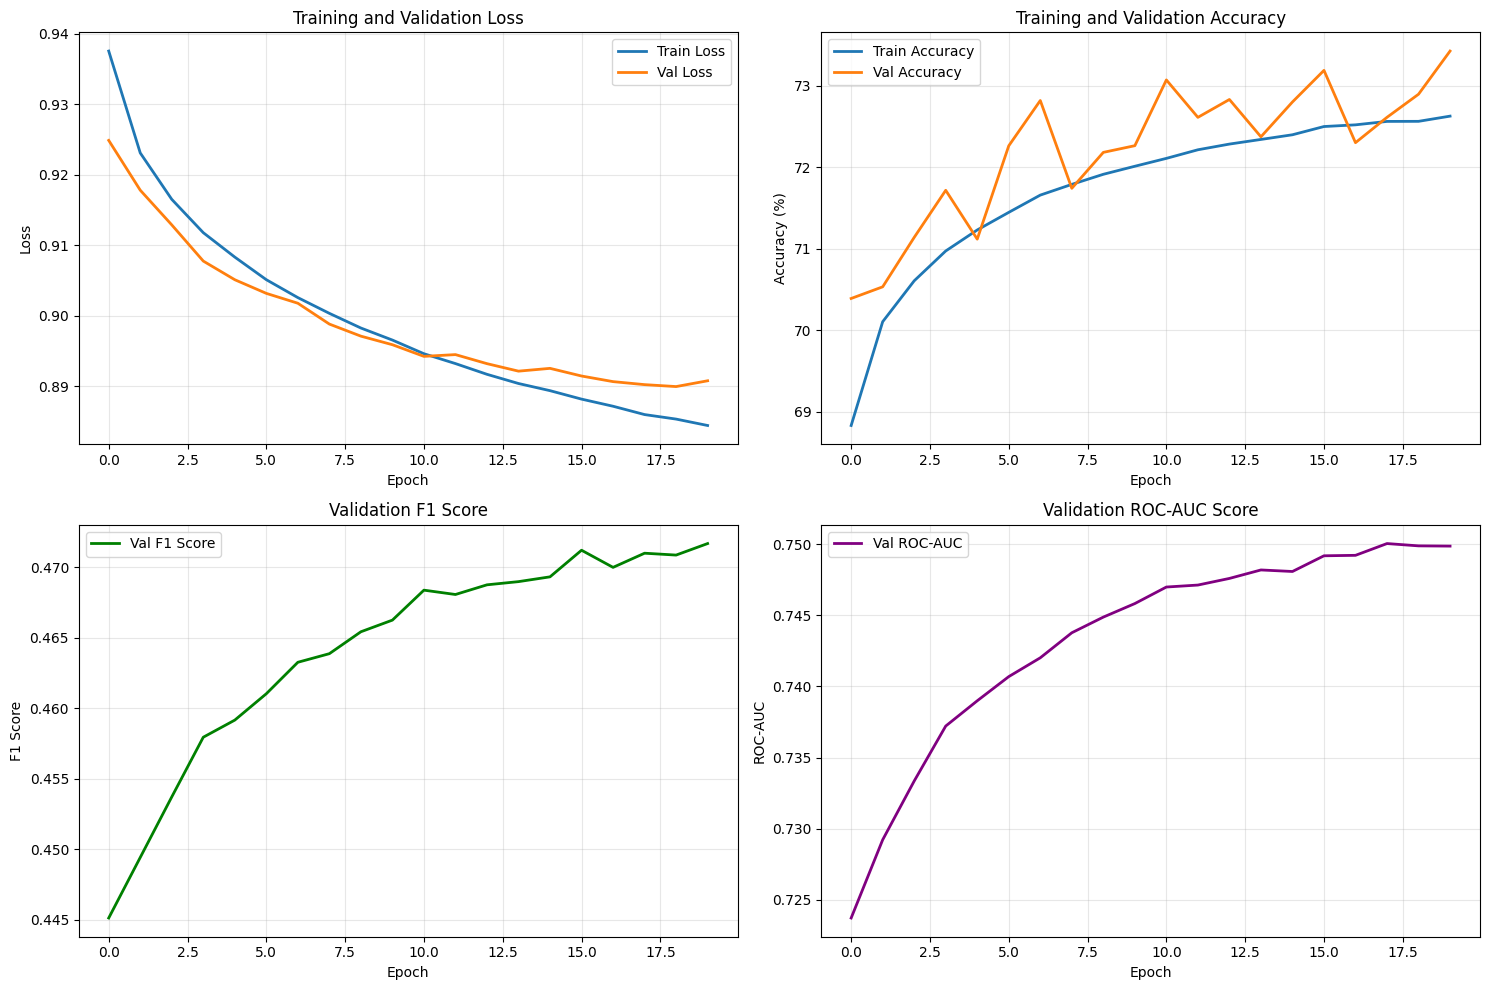

✓ Training history plot saved to ../data/models/training_history.png


In [17]:
# Plot training and validation metrics

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Accuracy
axes[0, 1].plot(history['train_acc'], label='Train Accuracy', linewidth=2)
axes[0, 1].plot(history['val_acc'], label='Val Accuracy', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: F1 Score
axes[1, 0].plot(history['val_f1'], label='Val F1 Score', color='green', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('Validation F1 Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: ROC-AUC
axes[1, 1].plot(history['val_roc_auc'], label='Val ROC-AUC', color='purple', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('ROC-AUC')
axes[1, 1].set_title('Validation ROC-AUC Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/models/training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training history plot saved to ../data/models/training_history.png")

In [1]:
# SAVE THE MODEL - This is the key step!

# Create models directory if it doesn't exist
Path('data/models').mkdir(parents=True, exist_ok=True)

# Save the model weights (Method 1 - recommended)
model_path = '../data/models/flight_delay_model.pth'
torch.save(model.state_dict(), model_path)
print(f"Model weights saved to: {model_path}")

# Save training history
history_path = '../dotnet/FlightPredictor.API/Data/training_history.json'
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f"Training history saved to: {history_path}")

# Save model metadata
metadata = {
    'model_version': '2.0',
    'trained_date': datetime.now().isoformat(),
    'input_features': X_train.shape[1],
    'architecture': {
        'input_size': X_train.shape[1],
        'hidden_layers': hidden_sizes,
        'output_size': 1
    },
    'training_samples': len(X_train),
    'validation_samples': len(X_val),
    'test_samples': len(X_test),
    'best_val_loss': best_val_loss,
    'epochs_trained': len(history['train_loss'])
}

metadata_path = '../dotnet/FlightPredictor.API/Data/model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"Model metadata saved to: {metadata_path}")

NameError: name 'Path' is not defined

In [21]:
# Export to ONNX

model.eval()  # Must be in eval mode for export

# Create a dummy input - shape must match your features
dummy_input = torch.randn(1, input_size).to(device)

# Export to ONNX
onnx_path = '../dotnet/FlightPredictor.API/Models/flight_delay_model.onnx'
torch.onnx.export(
    model,                              # Model to export
    dummy_input,                        # Example input
    onnx_path,                          # Where to save
    export_params=True,                 # Store trained weights
    opset_version=11,                   # ONNX version
    do_constant_folding=True,           # Optimize constants
    input_names=['input'],              # Input tensor name
    output_names=['output'],            # Output tensor name
    dynamic_axes={
        'input': {0: 'batch_size'},     # Variable batch size
        'output': {0: 'batch_size'}
    }
)

print(f"✓ Model exported to ONNX: {onnx_path}")

✓ Model exported to ONNX: ../dotnet/FlightPredictor.API/Models/flight_delay_model.onnx


C:\Users\davin\AppData\Local\Temp\ipykernel_16008\2248498367.py:10: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(
